In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

c:\Users\User\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
dataset = load_dataset("lukebarousse/data_jobs")

In [4]:
df = dataset['train'].to_pandas()

In [5]:
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [40]:
df_country = df[df['job_country'] == 'United States'].copy()

In [41]:
df_country['job_posted_month'] = df_country['job_posted_date'].dt.month_name()

In [42]:
df_country_jobs = df_country.pivot_table(
    index='job_posted_month', 
    columns='job_title_short',
    aggfunc='size'
)
df_country_jobs['month_number'] = pd.to_datetime(df_country_jobs.index, format='%B').month

In [43]:
df_country_jobs.sort_values('month_number', inplace=True)

In [44]:
df_country_jobs.drop(columns='month_number', inplace=True)

In [45]:
df_software_pivot = pd.read_csv('https://lukeb.co/software_csv', index_col='job_posted_month')

In [46]:
df_merged = df_country_jobs.merge(df_software_pivot, on='job_posted_month')

In [51]:
top_5 = (df_merged
         .sum()
         .sort_values(ascending=False)
         .head()
         .index
         .to_list()
         )

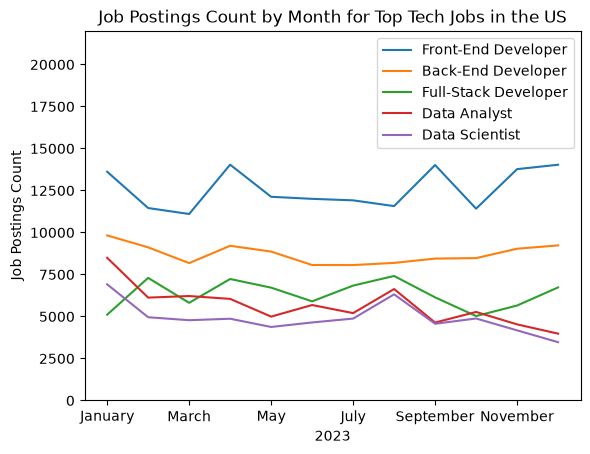

In [54]:
df_merged[top_5].plot(kind='line')
plt.xlabel('2023')
plt.ylabel('Job Postings Count')
plt.title('Job Postings Count by Month for Top Tech Jobs in the US')
plt.ylim(0,22000)
plt.legend()
plt.show()